In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error,mean_absolute_error, r2_score

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()

print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)

print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

In [3]:
ts = df["Avg_Yield_Total"]
ts.tail()

Date
2023-04-01    4128
2023-09-01    3877
2024-04-01    4599
2024-09-01    3914
2025-04-01    4760
Name: Avg_Yield_Total, dtype: int64

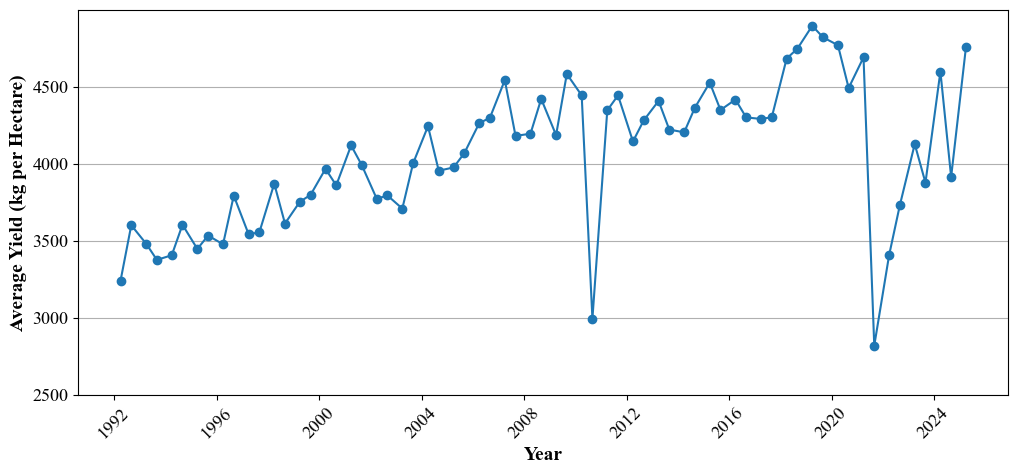

In [4]:
plt.figure(figsize=(12,5))
plt.plot(ts,marker="o",linewidth=1.5)

# plt.title("Average Yield Time Series")
plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylim(2500,)
plt.grid(axis='y')
plt.xticks(rotation=45)

plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

In [5]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [6]:
from statsmodels.tsa.stattools import adfuller, kpss
def adf_test(series, label="Series"):
    result = adfuller(series, autolag="AIC")
    p = result[1]
    print(f"\n  ADF Test [{label}]")
    print(f"    Statistic : {result[0]:.4f}")
    print(f"    p-value   : {p:.4f}")
    print(f"    Critical 5%: {result[4]['5%']:.4f}")
    print(f"    → {'✅ STATIONARY' if p < 0.05 else '❌ NON-STATIONARY — differencing needed'}")
    return p

adf_test(ts, "Original")


  ADF Test [Original]
    Statistic : -2.8805
    p-value   : 0.0477
    Critical 5%: -2.9072
    → ✅ STATIONARY


np.float64(0.04765698394075082)

In [7]:
# Automatically Find Best SARIMA Model
auto_model = auto_arima(train, 
                   seasonal=False,
                #    test='adf', 
                #    m=2, 
                   d=0,
                   stepwise=True, 
                   suppress_warnings=True,
                   trace=True)
print(auto_model)


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1032.052, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=754.360, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=755.995, Time=0.20 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=924.060, Time=0.34 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=752.405, Time=0.35 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=772.684, Time=0.33 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=764.669, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=759.923, Time=0.32 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=763.082, Time=0.38 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=787.067, Time=0.03 sec
 

In [8]:
# Generate a summary of the best model found
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   53
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -372.202
Date:                Sat, 06 Jun 2026   AIC                            752.405
Time:                        08:22:47   BIC                            760.286
Sample:                             0   HQIC                           755.435
                                 - 53                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    150.8441    219.108      0.688      0.491    -278.600     580.288
ar.L1          0.9625      0.056     17.192      0.000       0.853       1.072
ma.L1         -0.6987      0.148     -4.725      0.0

In [9]:
print(auto_model.fit(train))

 ARIMA(1,0,1)(0,0,0)[0] intercept


In [10]:
forecast = auto_model.predict(n_periods=len(test))
forecast

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    4380.544060
54    4367.102125
55    4354.164312
56    4341.711712
57    4329.726129
58    4318.190049
59    4307.086613
60    4296.399595
61    4286.113379
62    4276.212932
63    4266.683788
64    4257.512020
65    4248.684227
66    4240.187507
dtype: float64

In [11]:
dates = test.index
forecast_df = pd.DataFrame(index=dates)

forecast_df['Prediction'] = forecast.values.round(2)

# Season
forecast_df['Season'] = np.where(
    dates.month == 4,
    'Yala',
    'Maha'
)

# Agricultural year
forecast_df['Year'] = np.where(
    dates.month == 4,          # Yala starts in April
    dates.year,
    dates.year + 1            # Maha starts in September, assigned to next year
)

forecast_df = forecast_df[['Prediction', 'Year', 'Season']]

forecast_df

,Prediction,Year,Season
Date,,,
2018-09-01,4380.54,2019,Maha
2019-04-01,4367.10,2019,Yala
2019-09-01,4354.16,2020,Maha
2020-04-01,4341.71,2020,Yala
2020-09-01,4329.73,2021,Maha
2021-04-01,4318.19,2021,Yala
2021-09-01,4307.09,2022,Maha
2022-04-01,4296.40,2022,Yala
2022-09-01,4286.11,2023,Maha


In [12]:
forecast_df = pd.DataFrame(forecast.values.round(2), index= test.index, columns=['Prediction'])
forecast_df

,Prediction
Date,
2018-09-01,4380.54
2019-04-01,4367.10
2019-09-01,4354.16
2020-04-01,4341.71
2020-09-01,4329.73
2021-04-01,4318.19
2021-09-01,4307.09
2022-04-01,4296.40
2022-09-01,4286.11


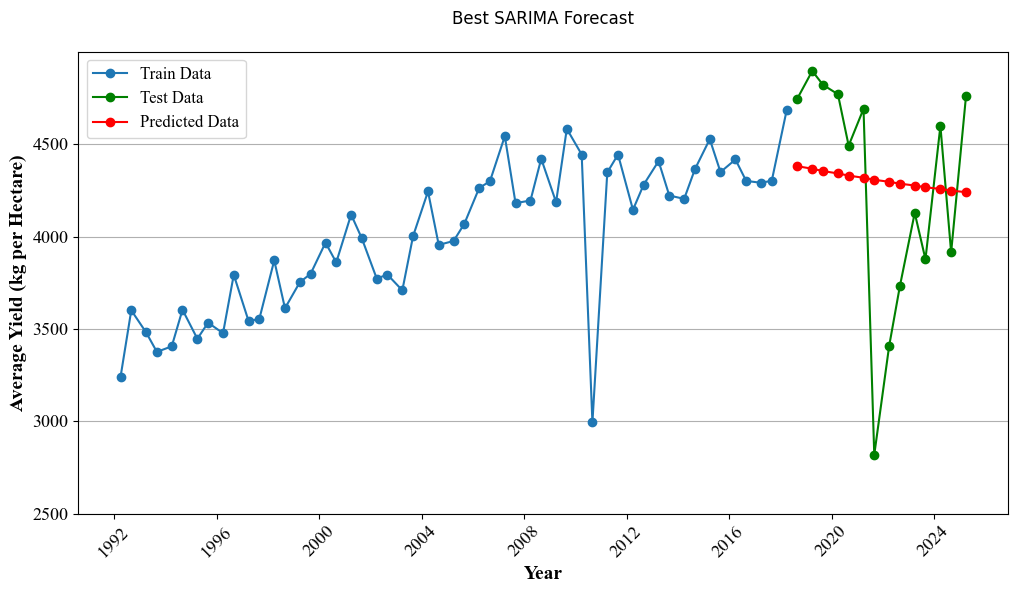

In [13]:
#Plot Forecast
plt.figure(figsize=(12,6))


plt.plot(train.index, train, label="Train Data",marker="o",linewidth=1.5)
plt.plot(test.index, test, label="Test Data", color="green",marker="o",linewidth=1.5)
plt.plot(test.index, forecast, label="Predicted Data", color="red",marker="o",linewidth=1.5)

plt.legend(prop={'size': 12, 'family':'Times New Roman'}  )

plt.title("Best SARIMA Forecast",pad=20)

plt.ylim(2500,)


plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)",fontsize=14,fontweight='bold',fontname='Times New Roman')

plt.grid(axis='y')
plt.xticks(rotation=45)

plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

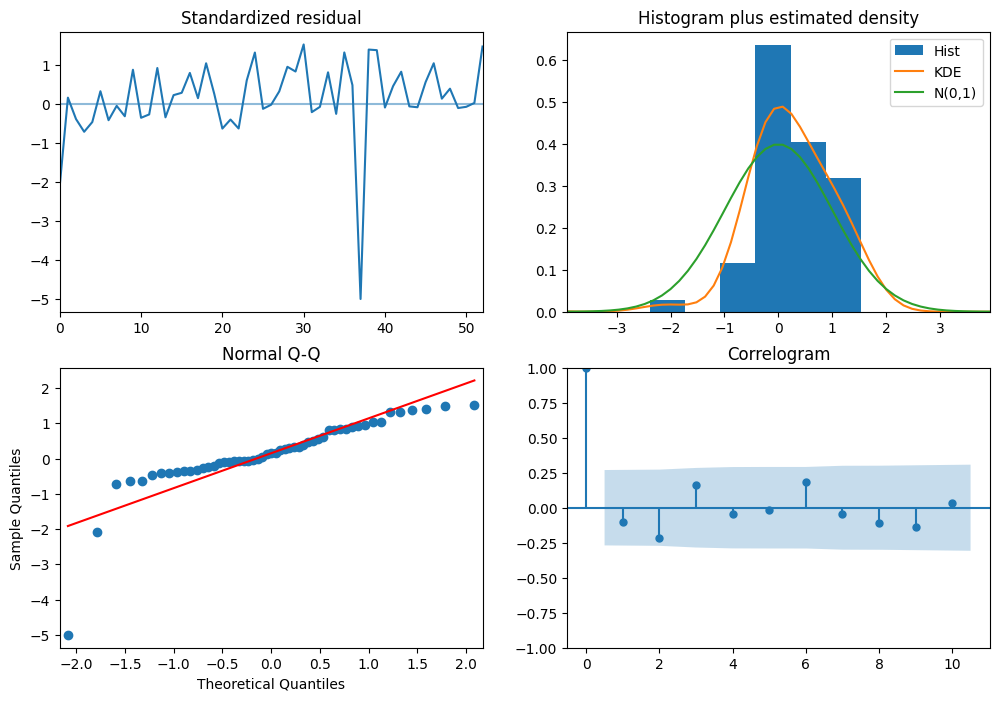

In [14]:
# Diagnostic plots
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [15]:
#Evaluate Model
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 595.64
MAPE : 13.08
MAE : 499.43
R²   : 0.0427


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



3-Year Future Forecast:
            Year Season  Prediction
2025-09-01  2026   Maha     4364.91
2026-04-01  2026   Yala     4269.36
2026-09-01  2027   Maha     4203.41
2027-04-01  2027   Yala     4157.90
2027-09-01  2028   Maha     4126.49
2028-04-01  2028   Yala     4104.81


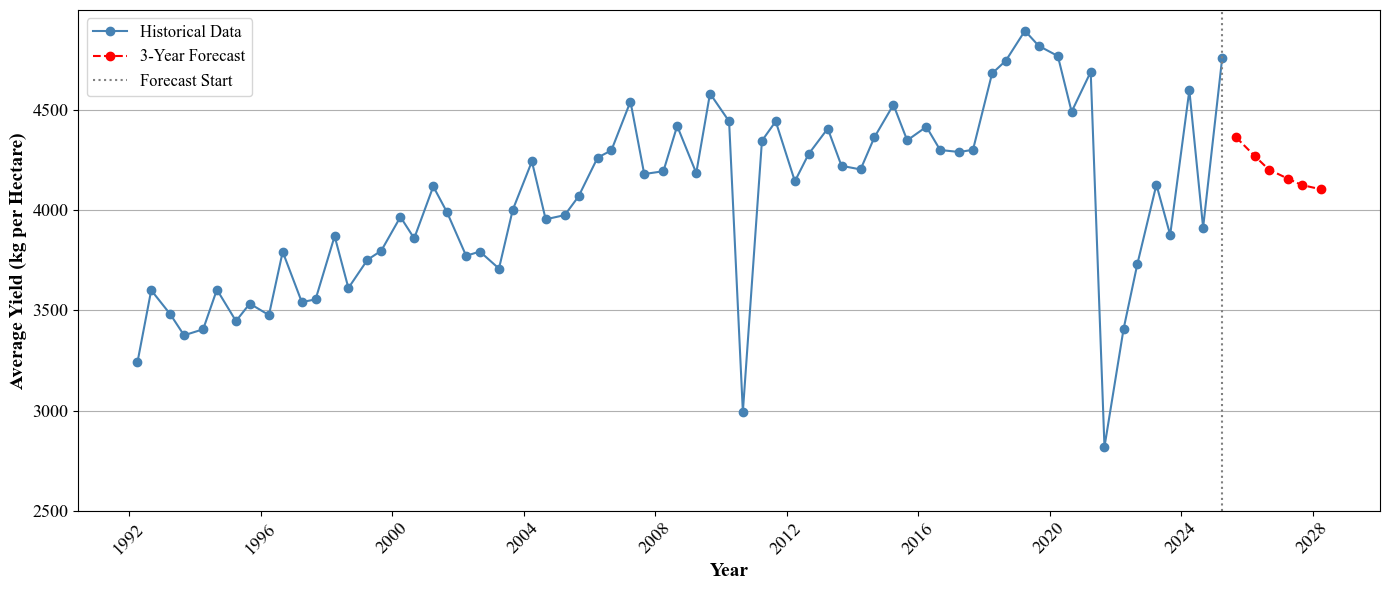

In [20]:
# ── Refit on FULL Data ─────────────────────────────────────────────────────────
auto_model.fit(ts)

# ── Build Future Dates (Apr ↔ Sep alternating) ────────────────────────────────
n_future  = 6        # 2 seasons × 3 years
last_date = ts.index[-1]

future_dates = []
current = last_date

for _ in range(n_future):
    if current.month == 4:
        next_date = current.replace(month=9)
    else:
        next_date = current.replace(month=4, year=current.year + 1)
    future_dates.append(next_date)
    current = next_date

future_dates = pd.DatetimeIndex(future_dates)

# ── Forecast + Confidence Intervals ───────────────────────────────────────────
future_forecast, conf_int = auto_model.predict(
    n_periods=n_future,
    return_conf_int=True
)

pred_vals = np.array(future_forecast).round(2)
lower     = conf_int[:, 0].round(2)
upper     = conf_int[:, 1].round(2)

# ── Build Forecast DataFrame ──────────────────────────────────────────────────
future_df = pd.DataFrame({
    'Prediction' : pred_vals,
    # 'Lower_95'   : lower,
    # 'Upper_95'   : upper
}, index=future_dates)

future_df['Season'] = np.where(future_dates.month == 4, 'Yala', 'Maha')

future_df['Year'] = np.where(
    future_dates.month == 4,
    future_dates.year,
    future_dates.year + 1
)

future_df = future_df[['Year', 'Season', 'Prediction']]

print("\n3-Year Future Forecast:")
print(future_df.to_string())

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 6))

plt.plot(ts.index, ts,
         label="Historical Data",
         marker="o", linewidth=1.5, color='steelblue')

plt.plot(future_dates, pred_vals,
         label="3-Year Forecast",
         marker="o", linewidth=1.5, color="red", linestyle='--')

# plt.fill_between(future_dates, lower, upper,
#                  color="red", alpha=0.15,
#                  label="95% Confidence Interval")

plt.axvline(x=last_date, color='gray',
            linestyle=':', linewidth=1.5,
            label='Forecast Start')

plt.xlabel("Year",                 fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)", fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.legend(prop={'size': 12, 'family': 'Times New Roman'})
plt.grid(axis='y')
plt.xticks(rotation=45, fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')
plt.ylim(2500,)
plt.tight_layout()
plt.show()